In [1]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")

✅ Libraries imported successfully!
Pandas version: 3.0.1


In [2]:
# Cell 2: List files in your Data folder
import os
print("Files in current directory:")
for file in os.listdir('.'):
    if file.endswith(('.xlsx', '.xls', '.csv')):
        print(f"  📊 {file}")

Files in current directory:
  📊 Ask A Manager Salary Survey 2021 (Responses).xlsx
  📊 cleaned_warehouse_messy_data.csv
  📊 cleaned_warehouse_messy_data.xlsx
  📊 healthcare_messy_data.csv
  📊 messy_HR_data(half-cleaned).xlsx
  📊 messy_HR_data.csv
  📊 messy_IMDB_dataset.csv
  📊 Uncleaned_DS_jobs.csv
  📊 Uncleaned_DS_jobs.xlsx
  📊 warehouse_messy_data.csv
  📊 warehouse_messy_data.xlsx


In [4]:
# Cell 3: Load your Excel file
# Replace 'your_file.xlsx' with your actual filename
df = pd.read_excel('warehouse_messy_data.xlsx')

# Or for CSV:
# df = pd.read_csv('warehouse_messy_data.csv')

print(f"Loaded {len(df)} records")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 1000 records
Columns: ['Product ID', 'Product Name', 'Category', 'Warehouse', 'Location', 'Quantity', 'Price', 'Supplier', 'Status', 'Last Restocked']


,Product ID,Product Name,Category,Warehouse,Location,Quantity,Price,Supplier,Status,Last Restocked
0,1102,Gadget Y,Electronics,Warehouse 2,Aisle 1,300,9.99,Supplier C,In Stock,NaN
1,1435,Gadget Y,Electronics,Warehouse 2,Aisle 4,200,19.99,Supplier C,Out of Stock,NaN
2,1860,Widget A,Clothing,Warehouse 2,Aisle 3,100,19.99,Supplier B,In Stock,20/12/2022
3,1270,Gadget Z,Toys,Warehouse 2,Aisle 4,50,49.99,Supplier B,In Stock,20/12/2022
4,1106,Widget A,Furniture,Warehouse 3,Aisle 3,200,9.99,Supplier D,Out of Stock,25/04/2023


✅ Setup complete
📊 Dataset shape: (1000, 10)
📋 Columns: ['Product ID', 'Product Name', 'Category', 'Warehouse', 'Location', 'Quantity', 'Price', 'Supplier', 'Status', 'Last Restocked']

🔍 First 5 rows:
📊 Missing Values Analysis:
                Missing Count  Missing %
Last Restocked            200       20.0


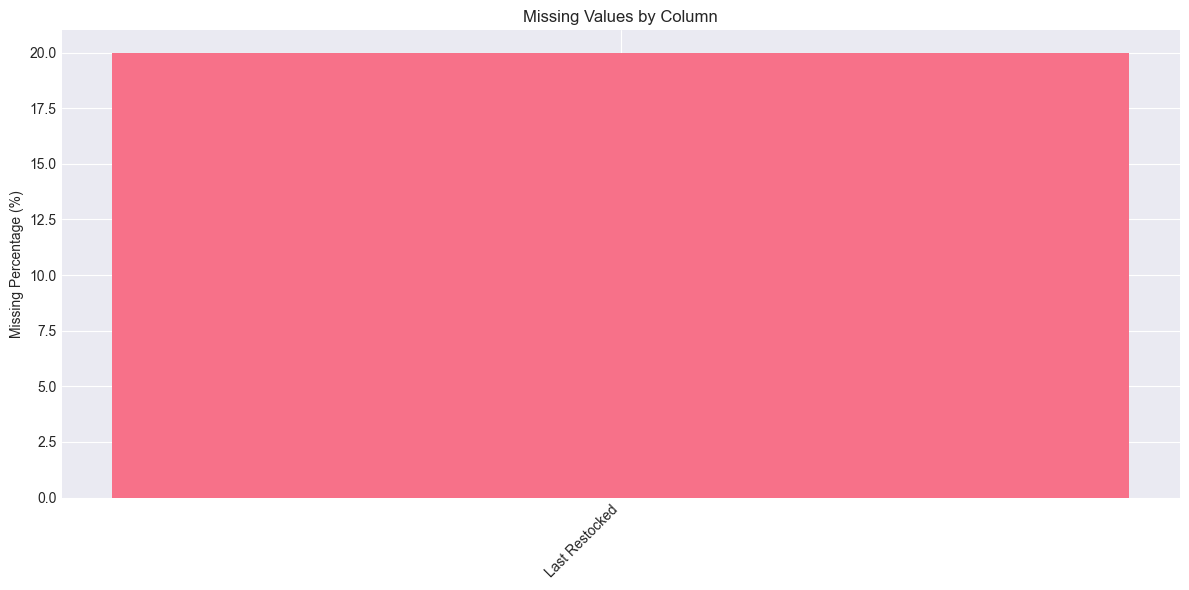


✅ VALIDATION REPORT


KeyError: 'quantity'

In [6]:
# %% [markdown]
# # Warehouse Data Analysis
# ## Handling Missing Values in Quantity and Last Restocked

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Setup complete")

# %%
# Load your data
df = pd.read_excel('warehouse_messy_data.xlsx')  # Change to your filename

# Create a copy for analysis
df_clean = df.copy()

print(f"📊 Dataset shape: {df_clean.shape}")
print(f"📋 Columns: {list(df_clean.columns)}")
print(f"\n🔍 First 5 rows:")
df_clean.head()

# %%
# Check missing values
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("📊 Missing Values Analysis:")
print(missing_df[missing_df['Missing Count'] > 0])

# %%
# Visualize missing data
plt.figure(figsize=(12, 6))
plt.bar(missing_df.index[missing_df['Missing Count'] > 0], 
        missing_df['Missing %'][missing_df['Missing Count'] > 0])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Missing Percentage (%)')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.show()

# %%
# Handle Quantity column
if 'quantity' in df_clean.columns:
    print(f"\n📦 Quantity Column Analysis:")
    print(f"Missing quantities: {df_clean['quantity'].isnull().sum()}")
    
    # Create tracking column
    df_clean['quantity_filled'] = False
    
    # Strategy 1: Discontinued products = 0
    if 'status' in df_clean.columns:
        discontinued_mask = (df_clean['quantity'].isnull()) & (df_clean['status'] == 'discontinued')
        df_clean.loc[discontinued_mask, 'quantity'] = 0
        df_clean.loc[discontinued_mask, 'quantity_filled'] = True
        print(f"  ✅ Filled {discontinued_mask.sum()} discontinued products with 0")
    
    # Strategy 2: Fill remaining with 0 with flag
    remaining_missing = df_clean['quantity'].isnull()
    df_clean.loc[remaining_missing, 'quantity'] = 0
    df_clean.loc[remaining_missing, 'quantity_filled'] = True
    print(f"  ✅ Filled {remaining_missing.sum()} remaining missing with 0")
    
    print(f"\n📊 Quantity summary after filling:")
    print(df_clean['quantity'].describe())

# %%
# Handle Last Restocked column
if 'last_restocked' in df_clean.columns:
    print(f"\n📅 Last Restocked Column Analysis:")
    print(f"Missing restock dates: {df_clean['last_restocked'].isnull().sum()}")
    
    # Create status column
    df_clean['restock_status'] = 'Active'
    
    # Strategy 1: New products (added in last 30 days)
    if 'date_added' in df_clean.columns:
        new_mask = (df_clean['last_restocked'].isnull()) & \
                   (df_clean['date_added'] > datetime.now() - timedelta(days=30))
        df_clean.loc[new_mask, 'restock_status'] = 'Never Restocked (New)'
        print(f"  🆕 Identified {new_mask.sum()} new products with no restock history")
    
    # Strategy 2: Discontinued products
    if 'status' in df_clean.columns:
        discontinued_mask = (df_clean['last_restocked'].isnull()) & \
                           (df_clean['status'] == 'discontinued')
        df_clean.loc[discontinued_mask, 'restock_status'] = 'Discontinued'
        print(f"  🚫 Identified {discontinued_mask.sum()} discontinued products")
    
    # Strategy 3: Flag remaining for review
    review_mask = (df_clean['last_restocked'].isnull()) & \
                  (df_clean['restock_status'] == 'Active')
    df_clean.loc[review_mask, 'restock_status'] = 'Data Gap - Needs Review'
    print(f"  ⚠️ {review_mask.sum()} products flagged for manual review")
    
    print(f"\n📊 Restock Status Distribution:")
    print(df_clean['restock_status'].value_counts())

# %%
# Validation checks
print("\n✅ VALIDATION REPORT")
print("="*50)

# Check for negative quantities
negative_qty = df_clean[df_clean['quantity'] < 0]
print(f"❌ Products with negative quantity: {len(negative_qty)}")

# Check for future dates
if 'last_restocked' in df_clean.columns:
    future_dates = df_clean[df_clean['last_restocked'] > datetime.now()]
    print(f"❌ Products with future restock dates: {len(future_dates)}")

# Check zero quantity with restock date
if 'quantity' in df_clean.columns and 'last_restocked' in df_clean.columns:
    zero_with_restock = df_clean[(df_clean['quantity'] == 0) & 
                                  df_clean['last_restocked'].notna()]
    print(f"⚠️  Zero quantity but has restock date: {len(zero_with_restock)}")

print(f"\n✅ Data quality score: {(1 - len(negative_qty)/len(df_clean)) * 100:.1f}%")

# %%
# Save cleaned data
output_file = 'warehouse_data_cleaned.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df_clean.to_excel(writer, sheet_name='Cleaned_Data', index=False)
    
    # Add summary sheet
    summary = pd.DataFrame({
        'Metric': ['Original Records', 'Missing Quantity Filled', 'Restock Status Updated'],
        'Value': [len(df), 
                  df_clean['quantity_filled'].sum() if 'quantity_filled' in df_clean else 0,
                  len(df_clean[df_clean['restock_status'] != 'Active']) if 'restock_status' in df_clean else 0]
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)
    
    # Add flagged items sheet
    if 'restock_status' in df_clean:
        flagged = df_clean[df_clean['restock_status'] == 'Data Gap - Needs Review']
        if not flagged.empty:
            flagged.to_excel(writer, sheet_name='Needs_Review', index=False)

print(f"\n✅ Cleaned data saved to: {output_file}")
print(f"   Includes: Cleaned_Data, Summary, and Needs_Review sheets")

# %%
# Quick dashboard
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Quantity distribution
ax1 = axes[0, 0]
df_clean['quantity'].hist(bins=50, ax=ax1)
ax1.set_title('Quantity Distribution')
ax1.set_xlabel('Quantity')
ax1.set_ylabel('Frequency')

# Restock status pie
if 'restock_status' in df_clean:
    ax2 = axes[0, 1]
    df_clean['restock_status'].value_counts().plot(kind='pie', ax=ax2, autopct='%1.1f%%')
    ax2.set_title('Restock Status Distribution')

# Box plot by category if available
if 'category' in df_clean.columns:
    ax3 = axes[1, 0]
    df_clean.boxplot(column='quantity', by='category', ax=ax3, rot=45)
    ax3.set_title('Quantity by Category')
    ax3.set_xlabel('')
else:
    axes[1, 0].text(0.5, 0.5, 'Add "category" column for this view', 
                    ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('Quantity by Category (Not Available)')

# Missing data summary
ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')
summary_text = f"""
DATA QUALITY SUMMARY
{'='*40}

Total Records: {len(df_clean)}
Columns: {len(df_clean.columns)}

Quantity Column:
- Missing originally: {df['quantity'].isnull().sum() if 'quantity' in df else 'N/A'}
- Filled with 0: {df_clean['quantity_filled'].sum() if 'quantity_filled' in df_clean else 'N/A'}

Restock Date:
- Missing originally: {df['last_restocked'].isnull().sum() if 'last_restocked' in df else 'N/A'}
- New products: {new_mask.sum() if 'new_mask' in locals() else 'N/A'}
- Discontinued: {discontinued_mask.sum() if 'discontinued_mask' in locals() else 'N/A'}
- Needs review: {review_mask.sum() if 'review_mask' in locals() else 'N/A'}
"""
ax4.text(0.1, 0.9, summary_text, transform=ax4.transAxes, fontsize=10, 
         verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.show()

print("\n✅ Analysis complete! Check the output file and visualizations above.")